In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/content/synthetic_fraud_dataset.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
display(df.head())

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
# Generate UPI IDs (from previous notebook state)
banks = ["icici", "sbi", "hdfc", "axis", "kotak", "pnb", "boi"]
base_names = df['Merchant_Category'].str.replace(" ", "").str.lower()
numbers = np.random.randint(100, 999, size=len(df))
bank_names = np.random.choice(banks, size=len(df))
df['Merchant_UPI_ID'] = base_names + numbers.astype(str) + "@" + bank_names

# Reorder columns → insert after Merchant_Category
cols = df.columns.tolist()
insert_at = cols.index("Merchant_Category") + 1
cols = cols[:insert_at] + ["Merchant_UPI_ID"] + cols[insert_at:-1] + [cols[-1]]
df = df[cols]

# Drop duplicate columns if any
df = df.loc[:, ~df.columns.duplicated()]

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)

display(df.head())

Shape of dataset: (50000, 22)

Column names:
 Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'Merchant_UPI_ID', 'IP_Address_Flag',
       'Previous_Fraudulent_Activity', 'Daily_Transaction_Count',
       'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Type',
       'Card_Age', 'Transaction_Distance', 'Authentication_Method',
       'Risk_Score', 'Is_Weekend', 'Fraud_Label'],
      dtype='object')


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,Merchant_UPI_ID,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,travel481@hdfc,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,clothing427@axis,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,restaurants357@boi,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,clothing952@pnb,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,electronics482@axis,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
# Data Inspection and Exploration
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   Merchant_UPI_ID               50000 non-null  object 
 10  IP_Address_Flag               50000 non-null  int64  
 11  Previous_Fraudulent_Activity  50000 non-null  int64  
 12  Daily_Transaction_Count       50000 non-null 

In [ ]:
print("\nDataset describe:")
df.describe()


Dataset describe:


,Transaction_Amount,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.05020,0.098400,7.485240,255.271924,2.003540,119.999940,2499.164155,0.501556,0.299640,0.321340
std,98.687292,28760.458557,0.21836,0.297858,4.039637,141.382279,1.414273,68.985817,1442.013834,0.287774,0.458105,0.466996
min,0.000000,500.480000,0.00000,0.000000,1.000000,10.000000,0.000000,1.000000,0.250000,0.000100,0.000000,0.000000
25%,28.677500,25355.995000,0.00000,0.000000,4.000000,132.087500,1.000000,60.000000,1256.497500,0.254000,0.000000,0.000000
50%,69.660000,50384.430000,0.00000,0.000000,7.000000,256.085000,2.000000,120.000000,2490.785000,0.502250,0.000000,0.000000
75%,138.852500,75115.135000,0.00000,0.000000,11.000000,378.032500,3.000000,180.000000,3746.395000,0.749525,1.000000,1.000000
max,1174.140000,99998.310000,1.00000,1.000000,14.000000,500.000000,4.000000,239.000000,4999.930000,1.000000,1.000000,1.000000


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
Merchant_UPI_ID                 0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64


In [ ]:
print("\nFraud vs Safe counts:\n", df['Fraud_Label'].value_counts())
print("\nFraud vs Safe percentage:\n", df['Fraud_Label'].value_counts(normalize=True) * 100)


Fraud vs Safe counts:
 Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Fraud vs Safe percentage:
 Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


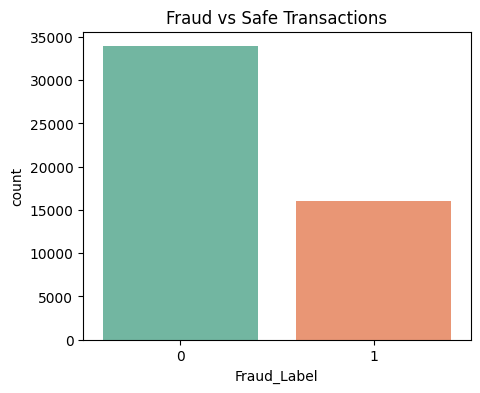

In [ ]:
# Plot target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Fraud_Label', data=df, palette="Set2", hue='Fraud_Label', legend=False)
plt.title("Fraud vs Safe Transactions")
plt.show()

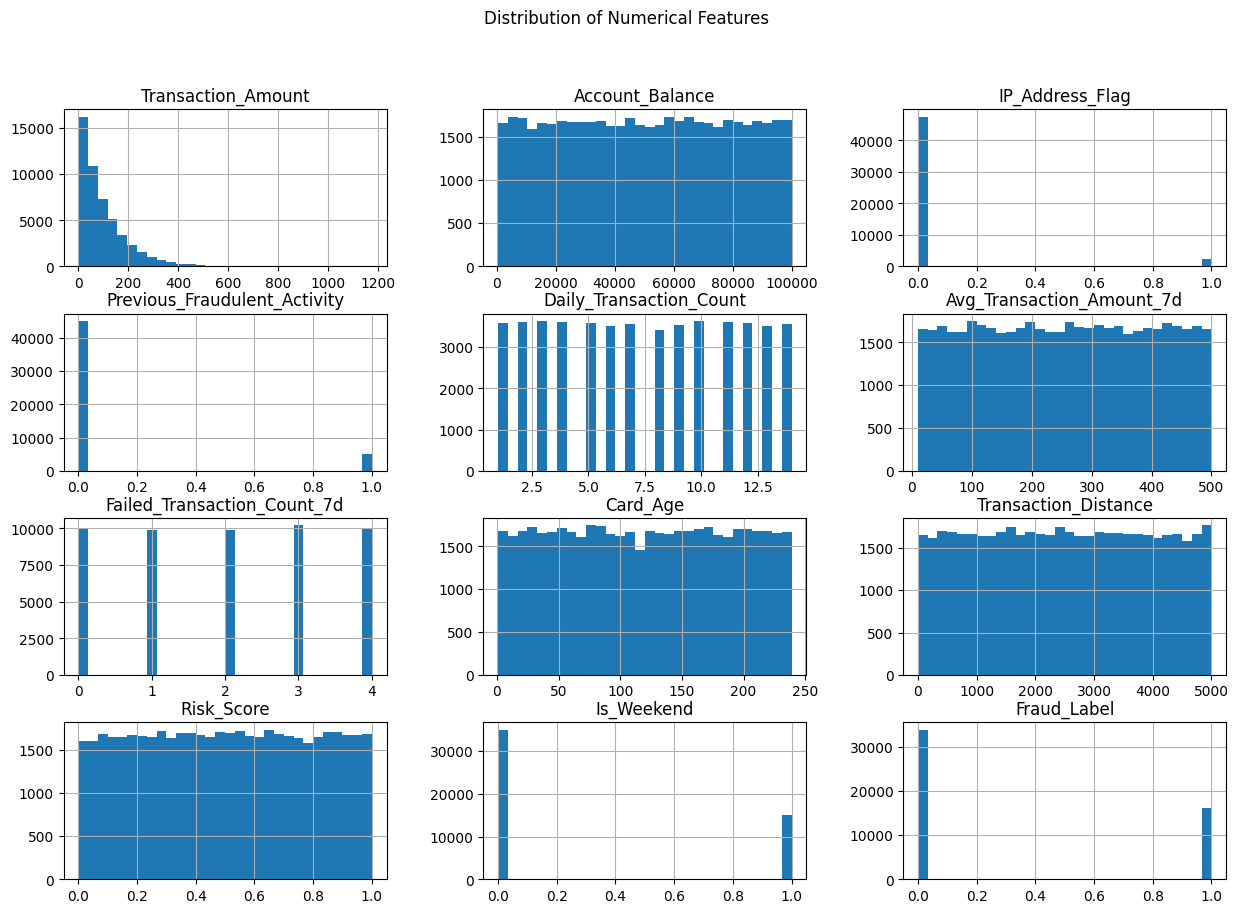

In [ ]:
# Histograms for numeric columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

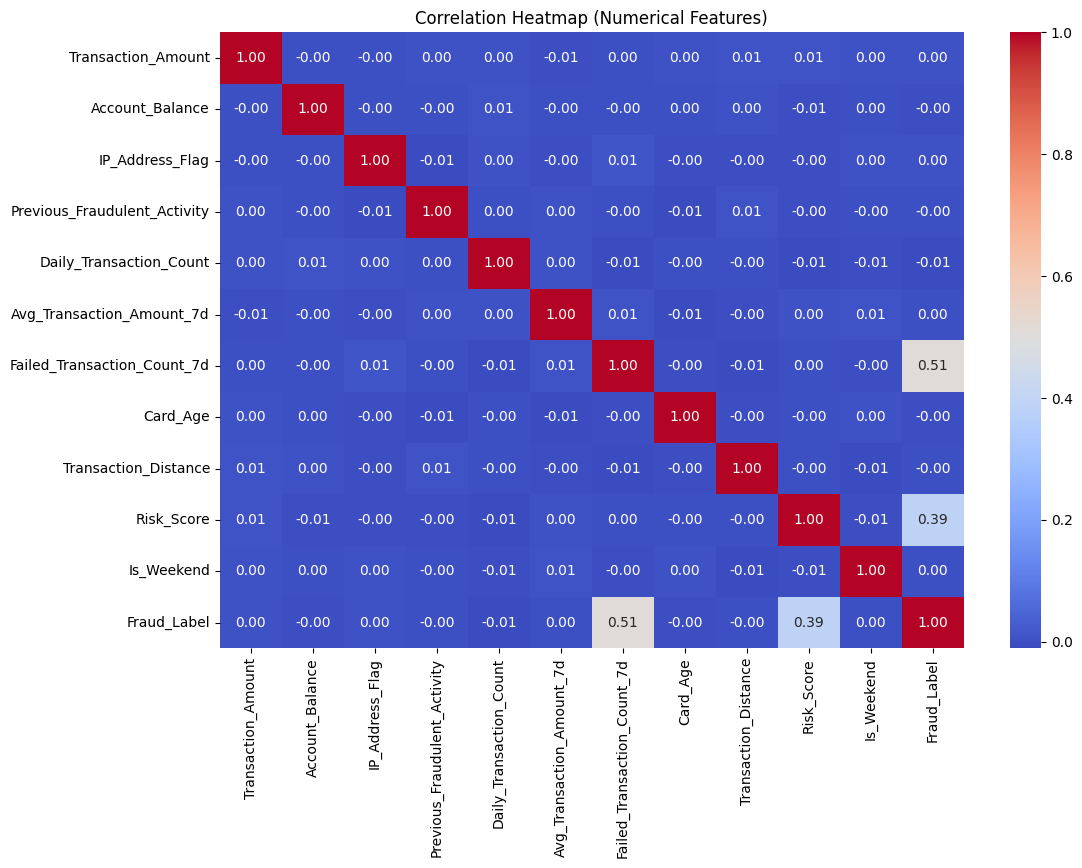

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [ ]:
# ----------------- 1. Data Preprocessing -----------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features & target
X = df.drop(columns=['Fraud_Label'])  # Change target column if needed
y = df['Fraud_Label']

# Drop rows with NaN in the target variable
nan_rows = y.isnull()
X = X[~nan_rows]
y = y[~nan_rows]


# Copy original features
X_original = X.copy()

# Identify numeric & categorical features
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Define transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))  # Sparse output for efficiency
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Apply preprocessing
X_train_pre = preprocessor.fit_transform(X_train)  # Keep sparse
X_test_pre = preprocessor.transform(X_test)

print("Preprocessed Train Shape:", X_train_pre.shape)
print("Preprocessed Test Shape:", X_test_pre.shape)

Numeric features: ['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend']
Categorical features: ['Transaction_ID', 'User_ID', 'Transaction_Type', 'Timestamp', 'Device_Type', 'Location', 'Merchant_Category', 'Merchant_UPI_ID', 'Card_Type', 'Authentication_Method']
Train shape: (40000, 21) Test shape: (10000, 21)
Preprocessed Train Shape: (40000, 110084)
Preprocessed Test Shape: (10000, 110084)


Original features: 110084
Reduced features: 50


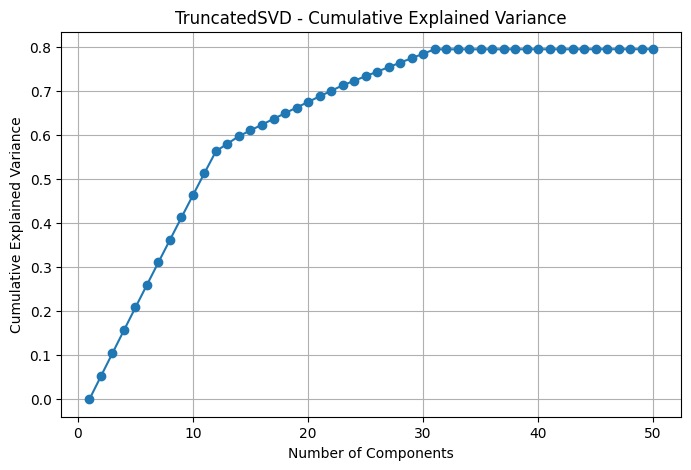

Explained Variance with 50 components: 79.55%


In [ ]:
# Dimensionality Reduction (TruncatedSVD)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

# Assuming X_train_pre and X_test_pre are available from the preprocessing step.

# TruncatedSVD (PCA for sparse data)
n_components = 50   # Using 50 components as used previously
svd = TruncatedSVD(n_components=n_components, random_state=42)

X_train_pca = svd.fit_transform(X_train_pre)
X_test_pca = svd.transform(X_test_pre)

print("Original features:", X_train_pre.shape[1])
print("Reduced features:", X_train_pca.shape[1])

# Explained Variance
explained_var_ratio = svd.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var_ratio)+1), explained_var_ratio, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("TruncatedSVD - Cumulative Explained Variance")
plt.grid(True)
plt.show()

print(f"Explained Variance with {n_components} components: {explained_var_ratio[-1]:.2%}")

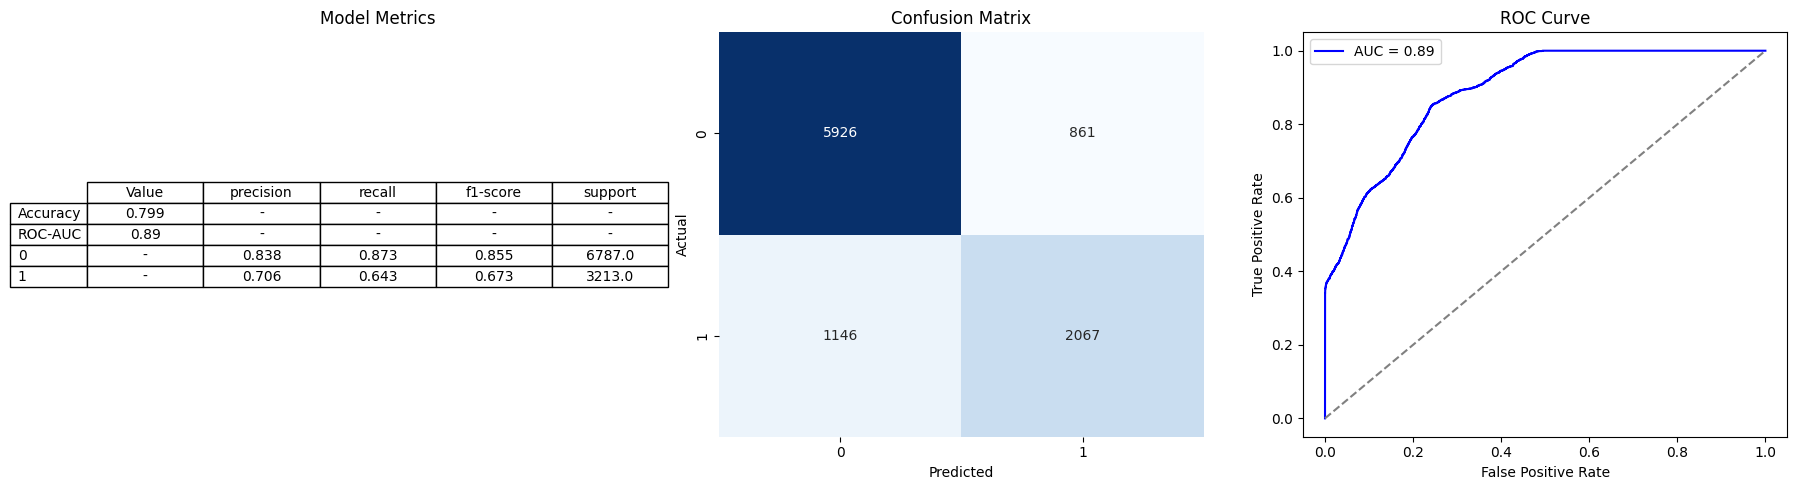

In [ ]:
# --- 6. Model Training and Evaluation: Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Logistic Regression
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train_pca, y_train)
y_pred_lr = log_reg.predict(X_test_pca)
y_prob_lr = log_reg.predict_proba(X_test_pca)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)
report = classification_report(y_test, y_pred_lr, output_dict=True)
cm = confusion_matrix(y_test, y_pred_lr)

# Convert classification report to DataFrame
report_df = pd.DataFrame(report).transpose().round(3)

# Replace NaN with dash "-"
report_df = report_df.replace([np.nan], "-")

# Summary DataFrame for accuracy and AUC
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC-AUC"],
    "Value": [round(acc, 3), round(roc_auc, 3)]
})

# ROC Curve values
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_val = auc(fpr, tpr)

# --- Plot in one row ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Metrics Table
axes[0].axis('tight')
axes[0].axis('off')

# Only take accuracy/auc + precision/recall/f1 for each class
table_data = pd.concat([summary_df.set_index("Metric"), report_df.iloc[:2, :]], axis=0)

# Replace any NaN again just in case
table_data = table_data.replace([np.nan], "-")

table = axes[0].table(cellText=table_data.values,
                      rowLabels=table_data.index,
                      colLabels=table_data.columns,
                      loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
axes[0].set_title("Model Metrics", fontsize=12)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1], [0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve", fontsize=12)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()


Test Accuracy: 0.7997
Test Loss Accuracy (1-Acc): 0.2003
Test Log Loss: 0.3795


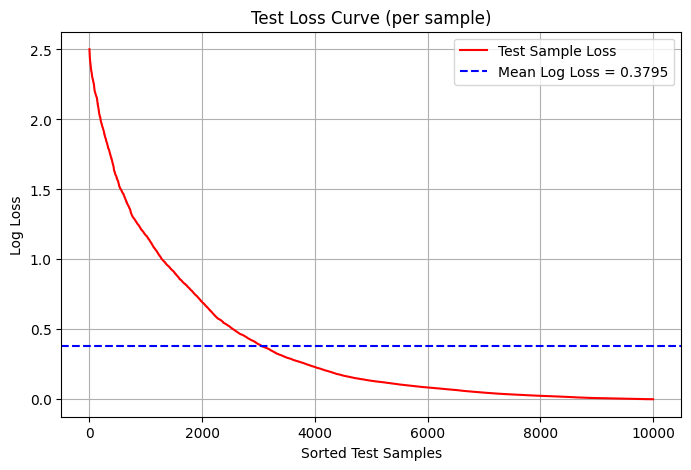

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

# Train model fully
log_reg = LogisticRegression(
    solver='saga',
    max_iter=5000,
    random_state=42
)
log_reg.fit(X_train_pca, y_train)

# Predictions on TEST set
y_prob_test = log_reg.predict_proba(X_test_pca)
y_pred_test = log_reg.predict(X_test_pca)

# Calculate accuracy and loss
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1-Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort by probability for smooth curve
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="red", label="Test Sample Loss")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

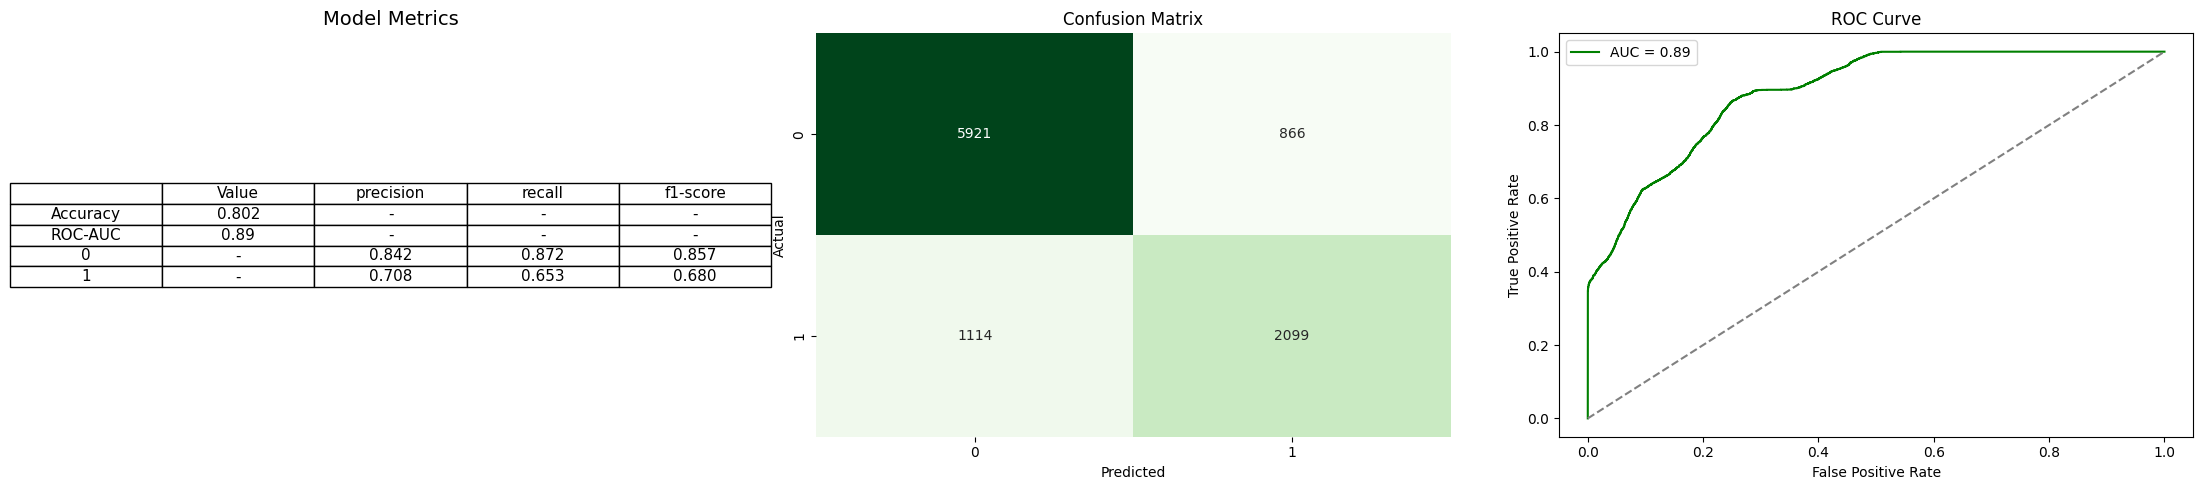

In [ ]:
# --- Linear Regression for Classification Evaluation ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_pca, y_train)

# Continuous predictions
y_pred_continuous = lin_reg.predict(X_test_pca)

# Convert to binary classification (threshold at 0.5)
y_pred_lin = (y_pred_continuous >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_lin)
roc_auc_val = roc_auc_score(y_test, y_pred_continuous)
report = classification_report(y_test, y_pred_lin, output_dict=True, labels=[0, 1])

# Create table data
rows = []
rows.append(["Accuracy", f"{accuracy:.3f}", "-", "-", "-"]) # Removed support column
rows.append(["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"])   # Removed support column
for label in ["0", "1"]:
    rows.append([
        label,
        "-",
        f"{report[label]['precision']:.3f}",
        f"{report[label]['recall']:.3f}",
        f"{report[label]['f1-score']:.3f}"
    ]) # Removed support column


columns = ["", "Value", "precision", "recall", "f1-score"] # Removed support column

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lin)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_continuous)
roc_auc_val = auc(fpr, tpr)

# --- Plot Layout ---
fig, axes = plt.subplots(1, 3, figsize=(22,5))

# 1. Metrics Table
axes[0].axis("off")
table = axes[0].table(cellText=rows,
                      colLabels=columns,
                      cellLoc="center",
                      loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)
axes[0].set_title("Model Metrics", fontsize=14)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="green", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.8025
Test Loss Accuracy (1-Acc): 0.1975
Test Log Loss: 0.3917


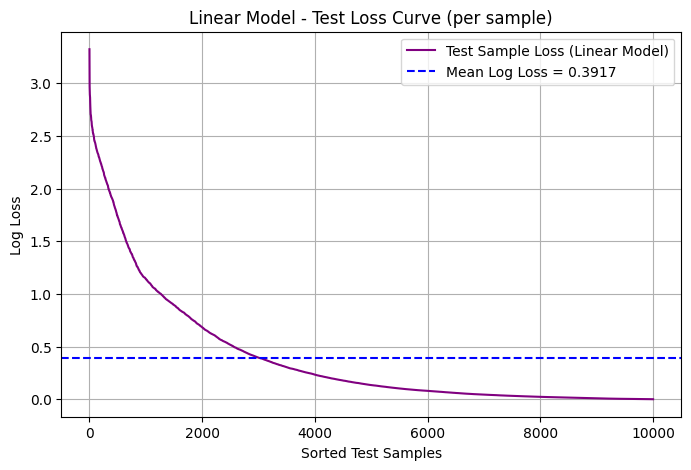

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

# -----------------------------
# Train Linear Model (Logistic with SGD)
# -----------------------------
lin_model = SGDClassifier(
    loss="log_loss",   # logistic regression loss
    max_iter=5000,
    tol=1e-3,
    random_state=42
)
lin_model.fit(X_train_pca, y_train)

# Predictions on TEST set
y_prob_test = lin_model.predict_proba(X_test_pca)
y_pred_test = lin_model.predict(X_test_pca)

# Calculate accuracy and loss
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1-Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort by probability for smooth curve
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="purple", label="Test Sample Loss (Linear Model)")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("Linear Model - Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

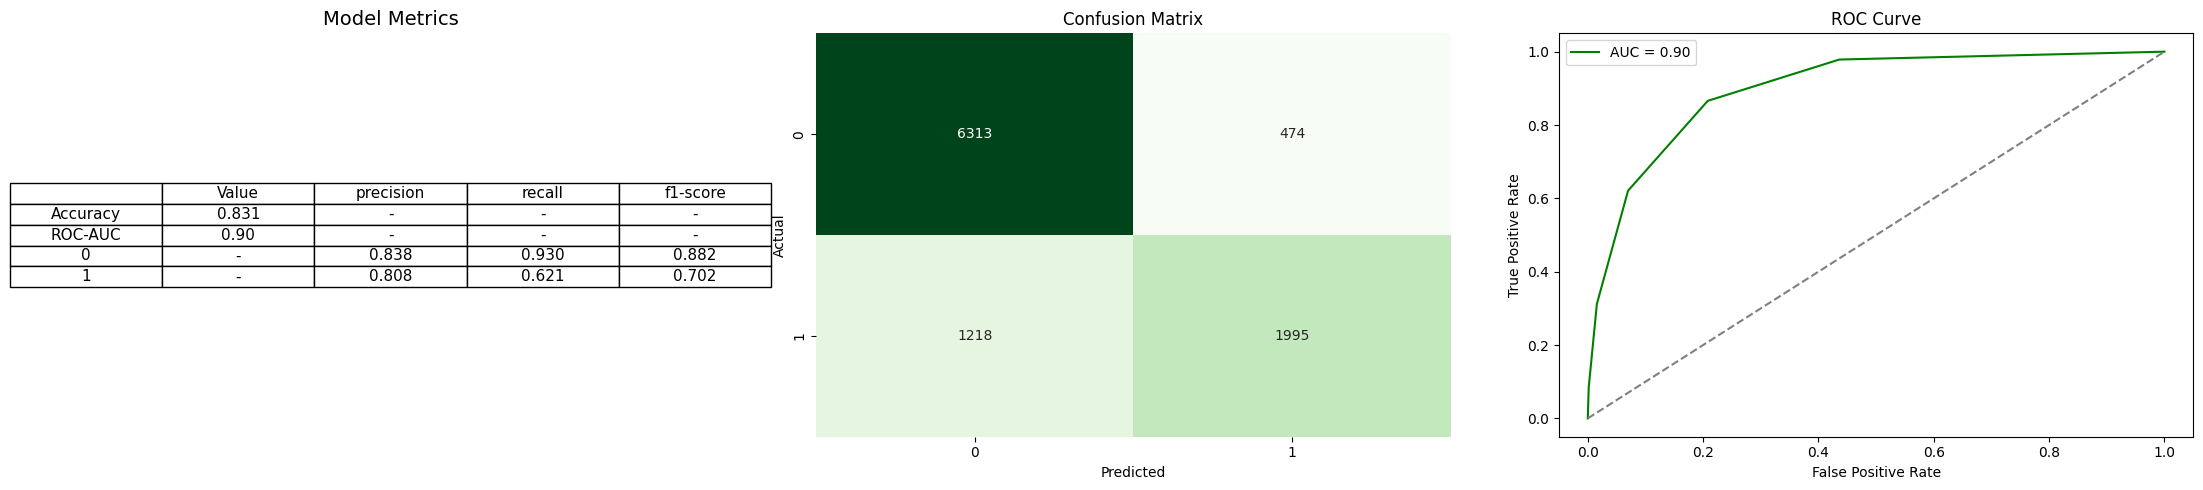

In [ ]:
# --- KNN Model Training and Evaluation ---
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_pca)
y_prob_knn = knn_model.predict_proba(X_test_pca)[:,1]  # Probabilities for ROC

# ----------------------
# Metrics Table
# ----------------------
accuracy = accuracy_score(y_test, y_pred_knn)
roc_auc_val = roc_auc_score(y_test, y_prob_knn)
report = classification_report(y_test, y_pred_knn, output_dict=True, labels=[0, 1])

# Create table data
rows = []
rows.append(["Accuracy", f"{accuracy:.3f}", "-", "-", "-"]) # Removed support column
rows.append(["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"])   # Removed support column
for label in ["0", "1"]:
    rows.append([
        label,
        "-",
        f"{report[label]['precision']:.3f}",
        f"{report[label]['recall']:.3f}",
        f"{report[label]['f1-score']:.3f}"
    ]) # Removed support column
columns = ["", "Value", "precision", "recall", "f1-score"] # Removed support column

# ----------------------
# Confusion Matrix
# ----------------------
cm = confusion_matrix(y_test, y_pred_knn)

# ----------------------
# ROC Curve
# ----------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc_val = auc(fpr, tpr)

# ----------------------
# Plot Layout (like Linear Regression code)
# ----------------------
fig, axes = plt.subplots(1, 3, figsize=(22,5))

# 1. Metrics Table
axes[0].axis("off")
table = axes[0].table(cellText=rows,
                      colLabels=columns,
                      cellLoc="center",
                      loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)
axes[0].set_title("Model Metrics", fontsize=14)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="green", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.8308
Test Loss Accuracy (1-Acc): 0.1692
Test Log Loss: 0.6172


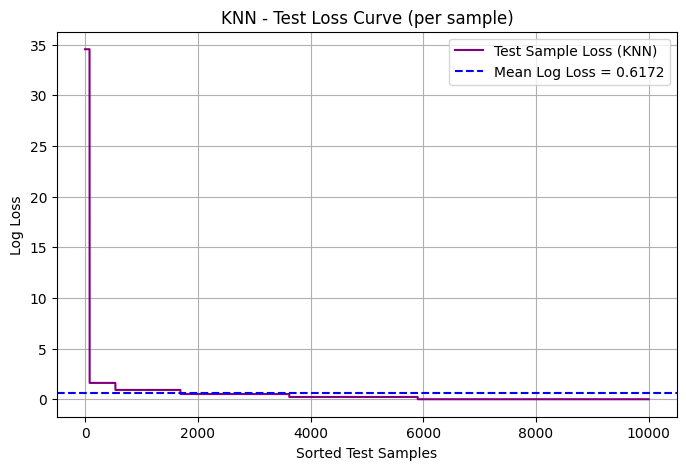

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss, accuracy_score

# -----------------------------
# Train KNN model
# -----------------------------
knn_model = KNeighborsClassifier(n_neighbors=5)  # you can tune k
knn_model.fit(X_train_pca, y_train)

# Predictions on TEST set
y_prob_test = knn_model.predict_proba(X_test_pca)
y_pred_test = knn_model.predict(X_test_pca)

# Calculate accuracy and loss
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1-Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort by probability for smooth curve
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="purple", label="Test Sample Loss (KNN)")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("KNN - Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

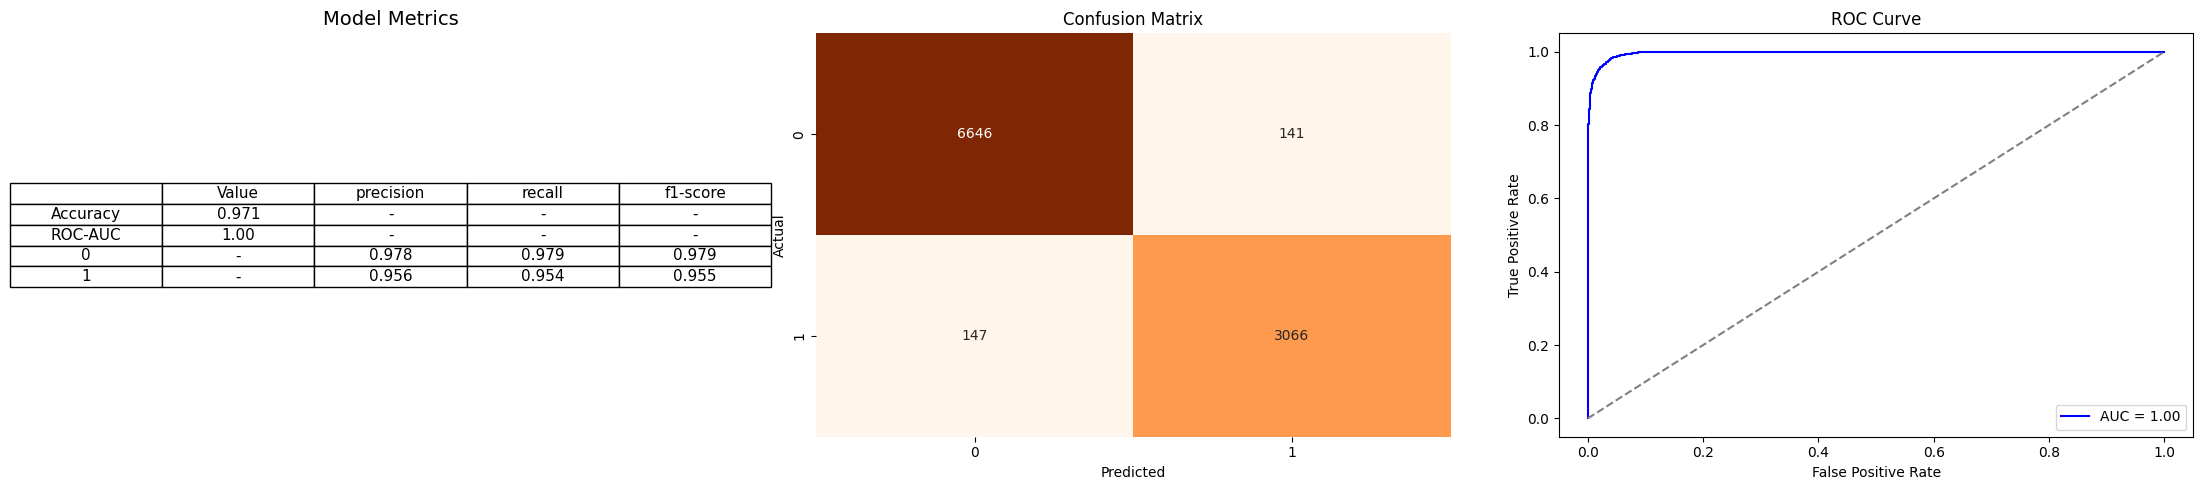

In [ ]:
# --- 7. Model Training and Evaluation: XGBoost ---
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Train XGBoost
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train_pca, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test_pca)
y_prob_xgb = xgb.predict_proba(X_test_pca)[:,1]

# Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
report = classification_report(y_test, y_pred_xgb, output_dict=True, labels=[0, 1])

# Convert classification report to DataFrame
report_df = pd.DataFrame(report).transpose().round(3)

# Create table data
rows = []
rows.append(["Accuracy", f"{accuracy:.3f}", "-", "-", "-"]) # Removed support column
rows.append(["ROC-AUC", f"{roc_auc:.2f}", "-", "-", "-"])   # Removed support column
for label in ["0", "1"]:
    rows.append([
        label,
        "-",
        f"{report[label]['precision']:.3f}",
        f"{report[label]['recall']:.3f}",
        f"{report[label]['f1-score']:.3f}"
    ]) # Removed support column

columns = ["", "Value", "precision", "recall", "f1-score"] # Removed support column

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_val = auc(fpr, tpr)

# --- Plot Layout ---
fig, axes = plt.subplots(1, 3, figsize=(22,5))

# 1. Metrics Table
axes[0].axis("off")
table = axes[0].table(cellText=rows,
                      colLabels=columns,
                      cellLoc="center",
                      loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)
axes[0].set_title("Model Metrics", fontsize=14)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.9733
Test Loss Accuracy (1-Acc): 0.0267
Test Log Loss: 0.0844


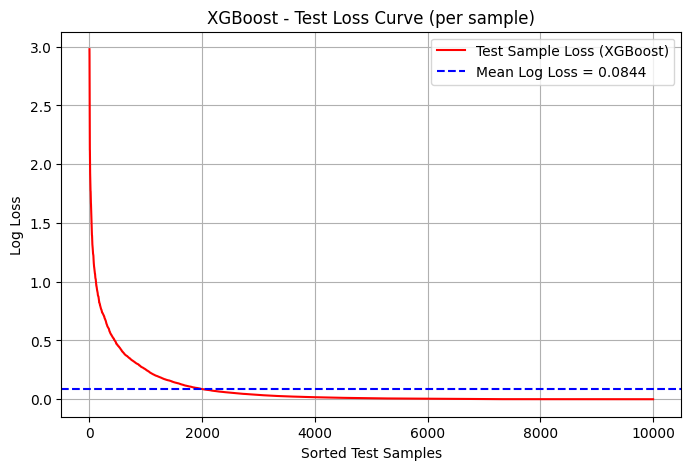

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, accuracy_score

# -----------------------------
# Train XGBoost model
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=300,       # number of trees
    learning_rate=0.1,      # step size
    max_depth=5,            # depth of trees
    random_state=42,
    # use_label_encoder=False, # Removed deprecated parameter
    eval_metric="logloss"   # avoid warning
)

xgb_model.fit(X_train_pca, y_train)

# Predictions on TEST set
y_prob_test = xgb_model.predict_proba(X_test_pca)
y_pred_test = xgb_model.predict(X_test_pca)

# Calculate accuracy and loss
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1-Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort by probability for smooth curve
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="red", label="Test Sample Loss (XGBoost)")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("XGBoost - Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[LightGBM] [Info] Start training from score -0.747575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


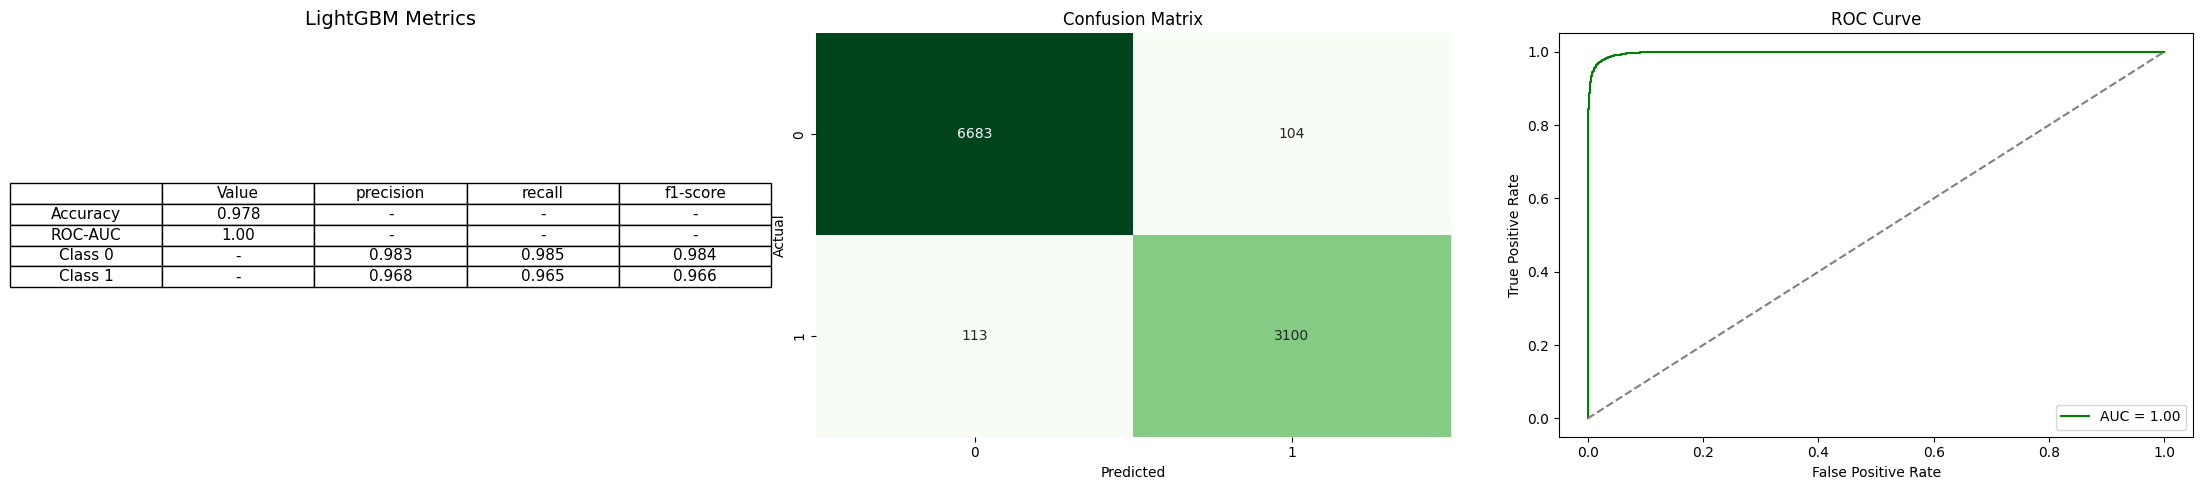

In [ ]:
# --- LightGBM Evaluation ---
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# --- Train LightGBM Model ---
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_pca, y_train)

# --- Predictions ---
y_pred_lgb = lgb_model.predict(X_test_pca)
y_prob_lgb = lgb_model.predict_proba(X_test_pca)[:, 1]

# --- Metrics ---
accuracy = accuracy_score(y_test, y_pred_lgb)
roc_auc_val = roc_auc_score(y_test, y_prob_lgb)
report = classification_report(y_test, y_pred_lgb, output_dict=True, labels=[0, 1])

# Table rows
rows = [["Accuracy", f"{accuracy:.3f}", "-", "-", "-"],
        ["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"]]
for label in ["0", "1"]:
    rows.append([
        f"Class {label}",
        "-",
        f"{report[label]['precision']:.3f}",
        f"{report[label]['recall']:.3f}",
        f"{report[label]['f1-score']:.3f}"
    ])
columns = ["", "Value", "precision", "recall", "f1-score"]

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_lgb)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_lgb)
roc_auc_val = auc(fpr, tpr)

# --- Plot Layout ---
fig, axes = plt.subplots(1, 3, figsize=(22,5))

# 1. Metrics Table
axes[0].axis("off")
table = axes[0].table(cellText=rows,
                      colLabels=columns,
                      cellLoc="center",
                      loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)
axes[0].set_title("LightGBM Metrics", fontsize=14)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="green", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()


[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[LightGBM] [Info] Start training from score -0.747575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test Accuracy: 0.9777
Test Loss Accuracy (1 - Acc): 0.0223
Test Log Loss: 0.0716


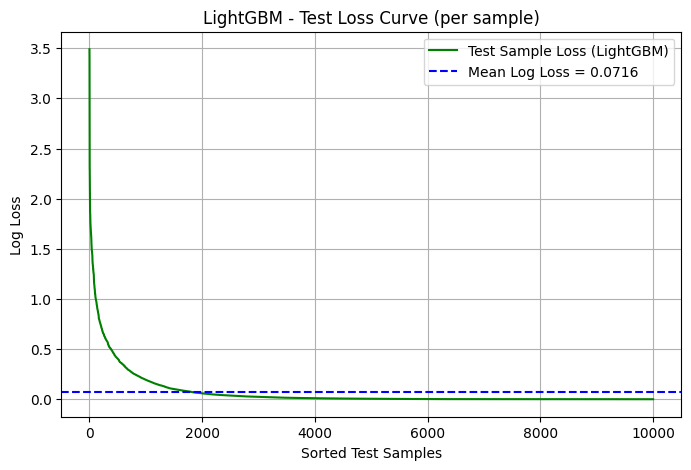

In [ ]:
# --- LightGBM Evaluation (Loss Curve Version) ---
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import log_loss, accuracy_score

# -----------------------------
# Train LightGBM model
# -----------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,       # number of trees
    learning_rate=0.1,      # step size
    max_depth=-1,           # unlimited depth
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_pca, y_train)

# Predictions on TEST set
y_prob_test = lgb_model.predict_proba(X_test_pca)
y_pred_test = lgb_model.predict(X_test_pca)

# -----------------------------
# Calculate accuracy and loss
# -----------------------------
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1 - Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort for smooth visualization
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="green", label="Test Sample Loss (LightGBM)")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("LightGBM - Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()


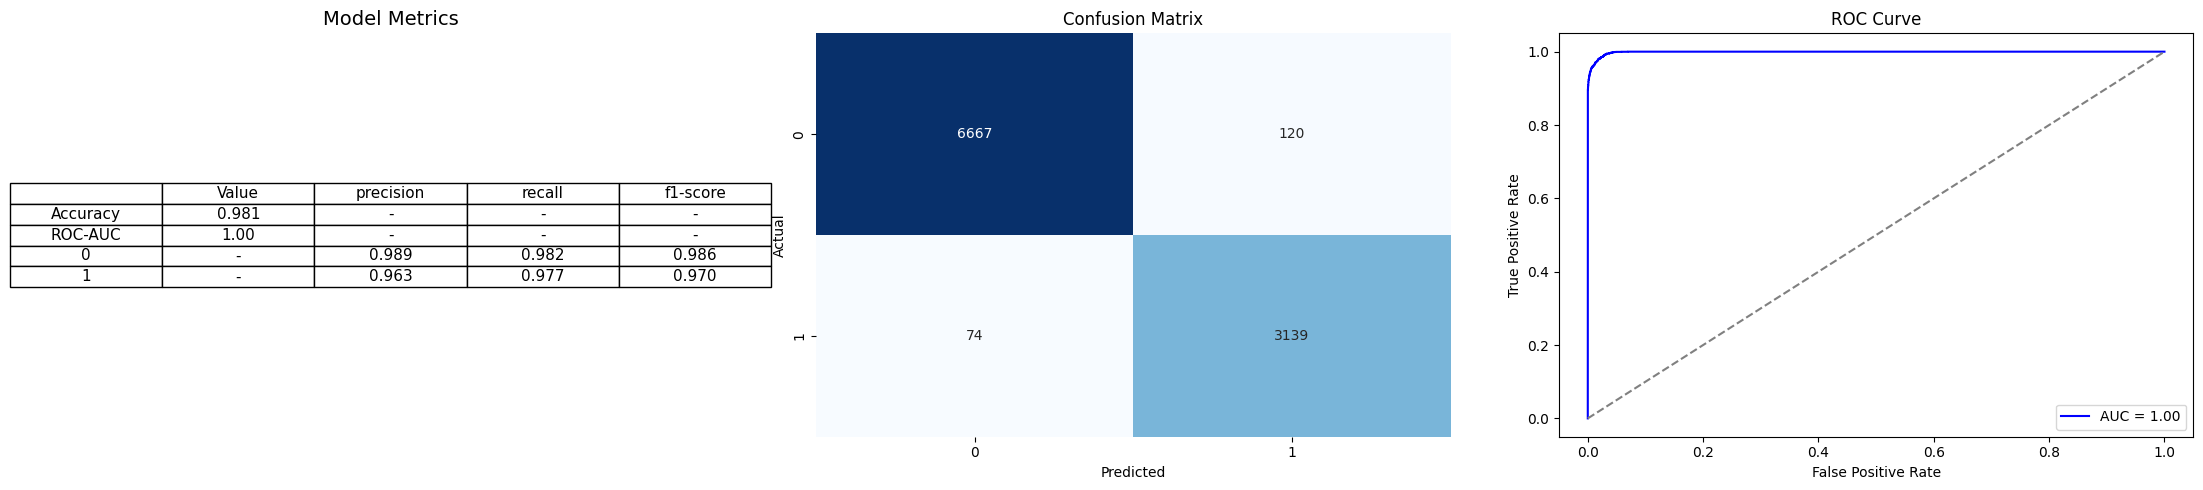

In [ ]:
# --- SVM Model Training and Evaluation ---
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Train SVM
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_pca)
y_prob_svm = svm_model.predict_proba(X_test_pca)[:,1]  # probability for ROC


# Metrics Table
accuracy = accuracy_score(y_test, y_pred_svm)
roc_auc_val = roc_auc_score(y_test, y_prob_svm)
report = classification_report(y_test, y_pred_svm, output_dict=True, labels=[0, 1])

# Create table data
rows = []
rows.append(["Accuracy", f"{accuracy:.3f}", "-", "-", "-"]) # Removed support column
rows.append(["ROC-AUC", f"{roc_auc_val:.2f}", "-", "-", "-"])   # Removed support column
for label in ["0", "1"]:
    rows.append([
        label,
        "-",
        f"{report[label]['precision']:.3f}",
        f"{report[label]['recall']:.3f}",
        f"{report[label]['f1-score']:.3f}"
    ]) # Removed support column
columns = ["", "Value", "precision", "recall", "f1-score"] # Removed support column

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc_val = auc(fpr, tpr)

# Plot Layout
fig, axes = plt.subplots(1, 3, figsize=(22,5))

# 1. Metrics Table
axes[0].axis("off")
table = axes[0].table(cellText=rows,
                      colLabels=columns,
                      cellLoc="center",
                      loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.2)
axes[0].set_title("Model Metrics", fontsize=14)

# 2. Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# 3. ROC Curve
axes[2].plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc_val:.2f}")
axes[2].plot([0,1],[0,1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

plt.tight_layout()
plt.show()

Test Accuracy: 0.9806
Test Loss Accuracy (1-Acc): 0.0194
Test Log Loss: 0.0404


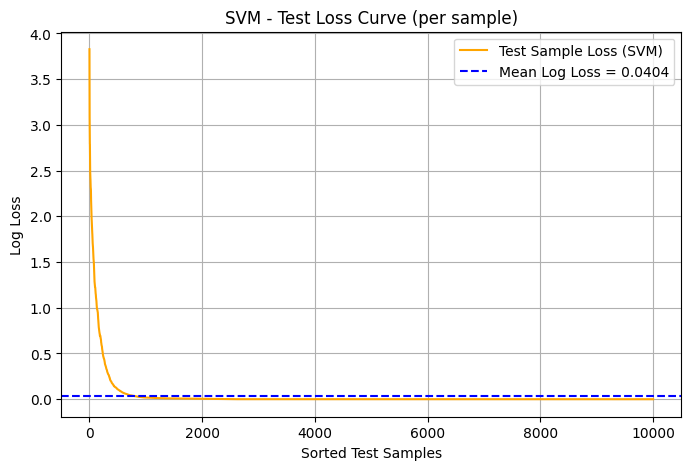

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import log_loss, accuracy_score

# -----------------------------
# Train SVM model (with probability)
# -----------------------------
svm_model = SVC(
    kernel="rbf",        # you can use "linear", "poly", "rbf", "sigmoid"
    probability=True,    # enable probability estimates (needed for log_loss)
    random_state=42
)
svm_model.fit(X_train_pca, y_train)
# Predictions on TEST set
y_prob_test = svm_model.predict_proba(X_test_pca)
y_pred_test = svm_model.predict(X_test_pca)

# Calculate accuracy and loss
acc = accuracy_score(y_test, y_pred_test)
loss_acc = 1 - acc
loss = log_loss(y_test, y_prob_test)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss Accuracy (1-Acc): {loss_acc:.4f}")
print(f"Test Log Loss: {loss:.4f}")

# -----------------------------
# Loss Curve Visualization
# -----------------------------
# Get predicted probability of the true class
true_class_probs = y_prob_test[np.arange(len(y_test)), y_test.astype(int)]

# Compute individual sample losses = -log(p_true)
sample_losses = -np.log(true_class_probs + 1e-15)

# Sort by probability for smooth curve
sorted_idx = np.argsort(true_class_probs)
sorted_losses = sample_losses[sorted_idx]

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, color="orange", label="Test Sample Loss (SVM)")
plt.axhline(loss, color="blue", linestyle="--", label=f"Mean Log Loss = {loss:.4f}")
plt.title("SVM - Test Loss Curve (per sample)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()

[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022949 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[LightGBM] [Info] Start training from score -0.747575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Model Comparison ---
Logistic Regression: Accuracy = 0.7993, ROC-AUC = 0.8897
Linear Regression: Accuracy = 0.8020, ROC-AUC = 0.8892
KNN: Accuracy = 0.8308, ROC-AUC = 0.8990
XGBoost: Accuracy = 0.9712, ROC-AUC = 0.9969
LightGBM: Accuracy = 0.9782, ROC-AUC = 0.9980
SVM: Accuracy = 0.9806, ROC-AUC = 0.9989


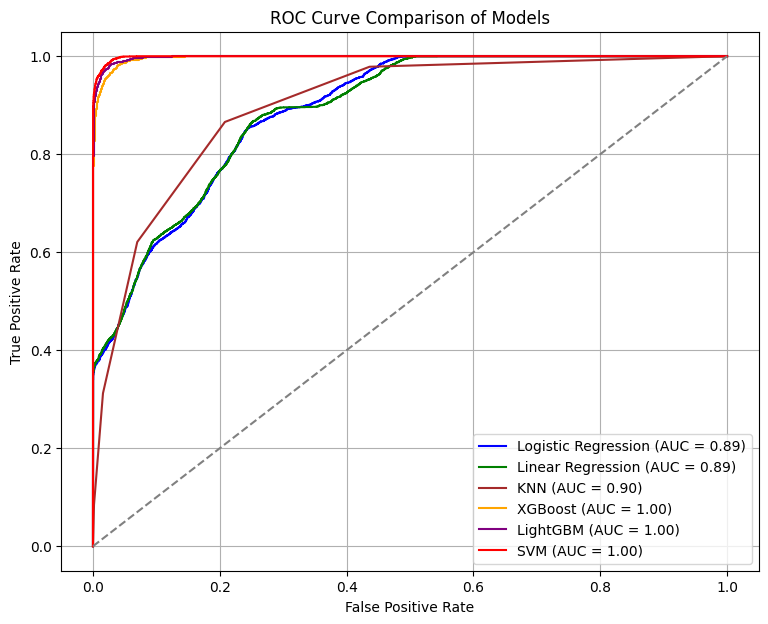

In [ ]:
# --- Model Comparison: Logistic, Linear, KNN, XGBoost, LightGBM, SVM ---
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Dictionaries to store results and ROC curves
results = {}
roc_curves = {}

# -------------------------
# 1. Logistic Regression
# -------------------------
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_pca, y_train)

y_pred_log = log_reg.predict(X_test_pca)
y_prob_log = log_reg.predict_proba(X_test_pca)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
roc_log = roc_auc_score(y_test, y_prob_log)
results["Logistic Regression"] = (acc_log, roc_log)

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_curves["Logistic Regression"] = (fpr_log, tpr_log, roc_log)


# -------------------------
# 2. Linear Regression
# -------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_train_pca, y_train)

y_pred_continuous = lin_reg.predict(X_test_pca)
y_pred_lin = (y_pred_continuous >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_lin)
roc_lin = roc_auc_score(y_test, y_pred_continuous)
results["Linear Regression"] = (acc_lin, roc_lin)

fpr_lin, tpr_lin, _ = roc_curve(y_test, y_pred_continuous)
roc_curves["Linear Regression"] = (fpr_lin, tpr_lin, roc_lin)


# -------------------------
# 3. KNN
# -------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)
y_prob_knn = knn.predict_proba(X_test_pca)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
roc_knn = roc_auc_score(y_test, y_prob_knn)
results["KNN"] = (acc_knn, roc_knn)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_curves["KNN"] = (fpr_knn, tpr_knn, roc_knn)


# -------------------------
# 4. XGBoost
# -------------------------
xgb = XGBClassifier(eval_metric="logloss", random_state=42)
xgb.fit(X_train_pca, y_train)

y_pred_xgb = xgb.predict(X_test_pca)
y_prob_xgb = xgb.predict_proba(X_test_pca)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
results["XGBoost"] = (acc_xgb, roc_xgb)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_curves["XGBoost"] = (fpr_xgb, tpr_xgb, roc_xgb)


# -------------------------
# 5. LightGBM
# -------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)
lgb_model.fit(X_train_pca, y_train)

y_pred_lgb = lgb_model.predict(X_test_pca)
y_prob_lgb = lgb_model.predict_proba(X_test_pca)[:, 1]

acc_lgb = accuracy_score(y_test, y_pred_lgb)
roc_lgb = roc_auc_score(y_test, y_prob_lgb)
results["LightGBM"] = (acc_lgb, roc_lgb)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
roc_curves["LightGBM"] = (fpr_lgb, tpr_lgb, roc_lgb)


# -------------------------
# 6. SVM
# -------------------------
svm = SVC(probability=True, kernel="rbf", random_state=42)
svm.fit(X_train_pca, y_train)

y_pred_svm = svm.predict(X_test_pca)
y_prob_svm = svm.predict_proba(X_test_pca)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_prob_svm)
results["SVM"] = (acc_svm, roc_svm)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_curves["SVM"] = (fpr_svm, tpr_svm, roc_svm)


# -------------------------
# Print Comparison Results
# -------------------------
print("\n--- Model Comparison ---")
for model, (acc, roc) in results.items():
    print(f"{model}: Accuracy = {acc:.4f}, ROC-AUC = {roc:.4f}")


# -------------------------
# Plot ROC Curves Together
# -------------------------
plt.figure(figsize=(9,7))
colors = {
    "Logistic Regression": "blue",
    "Linear Regression": "green",
    "KNN": "brown",
    "XGBoost": "orange",
    "LightGBM": "purple",
    "SVM": "red"
}

for model, (fpr, tpr, roc) in roc_curves.items():
    plt.plot(fpr, tpr, color=colors[model], label=f"{model} (AUC = {roc:.2f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison of Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 12854, number of negative: 27146
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.321350 -> initscore=-0.747575
[LightGBM] [Info] Start training from score -0.747575


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Model Comparison Results ===
Logistic Regression: Acc=0.7997, LossAcc=0.2003, LogLoss=0.3795
Linear Regression: Acc=0.8020, LossAcc=0.1980, LogLoss=0.3909
KNN: Acc=0.8308, LossAcc=0.1692, LogLoss=0.6172
XGBoost: Acc=0.9733, LossAcc=0.0267, LogLoss=0.0844
LightGBM: Acc=0.9782, LossAcc=0.0218, LogLoss=0.0676
SVM: Acc=0.9806, LossAcc=0.0194, LogLoss=0.0404


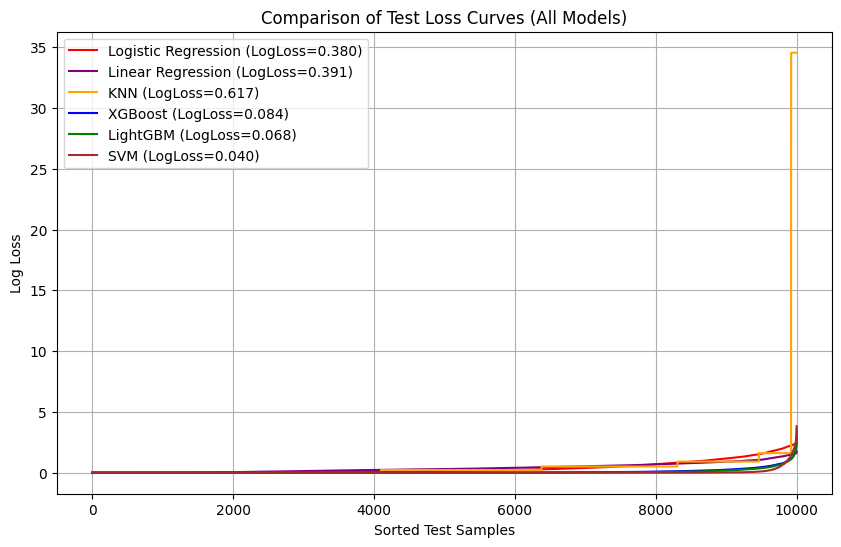

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score

# Dictionary to store results for all models
results = {}

# -----------------------------
# 1. Logistic Regression
# -----------------------------
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(solver="saga", max_iter=5000, random_state=42)
log_reg.fit(X_train_pca, y_train)
y_prob_lr = log_reg.predict_proba(X_test_pca)
y_pred_lr = log_reg.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred_lr)
results["Logistic Regression"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, y_prob_lr),
    "probs": y_prob_lr
}

# -----------------------------
# 2. Linear Regression (as classifier with threshold 0.5)
# -----------------------------
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train_pca, y_train)
y_prob_lin = lin_reg.predict(X_test_pca).clip(0, 1)  # clip to [0,1]
y_pred_lin = (y_prob_lin >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_lin)
results["Linear Regression"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, np.vstack([1-y_prob_lin, y_prob_lin]).T),
    "probs": np.vstack([1-y_prob_lin, y_prob_lin]).T
}

# -----------------------------
# 3. KNN
# -----------------------------
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_prob_knn = knn.predict_proba(X_test_pca)
y_pred_knn = knn.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred_knn)
results["KNN"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, y_prob_knn),
    "probs": y_prob_knn
}

# -----------------------------
# 4. XGBoost
# -----------------------------
from xgboost import XGBClassifier
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                          random_state=42, eval_metric="logloss")
xgb_model.fit(X_train_pca, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test_pca)
y_pred_xgb = xgb_model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred_xgb)
results["XGBoost"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, y_prob_xgb),
    "probs": y_prob_xgb
}

# -----------------------------
# 5. LightGBM
# -----------------------------
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)
lgb_model.fit(X_train_pca, y_train)
y_prob_lgb = lgb_model.predict_proba(X_test_pca)
y_pred_lgb = lgb_model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred_lgb)
results["LightGBM"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, y_prob_lgb),
    "probs": y_prob_lgb
}

# -----------------------------
# 6. SVM
# -----------------------------
from sklearn.svm import SVC
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_pca, y_train)
y_prob_svm = svm_model.predict_proba(X_test_pca)
y_pred_svm = svm_model.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred_svm)
results["SVM"] = {
    "acc": acc,
    "loss_acc": 1 - acc,
    "log_loss": log_loss(y_test, y_prob_svm),
    "probs": y_prob_svm
}

# -----------------------------
# Print Results
# -----------------------------
print("\n=== Model Comparison Results ===")
for model, vals in results.items():
    print(f"{model}: Acc={vals['acc']:.4f}, LossAcc={vals['loss_acc']:.4f}, LogLoss={vals['log_loss']:.4f}")

# -----------------------------
# Combined Loss Curve Plot
# -----------------------------
plt.figure(figsize=(10,6))

colors = {
    "Logistic Regression": "red",
    "Linear Regression": "purple",
    "KNN": "orange",
    "XGBoost": "blue",
    "LightGBM": "green",
    "SVM": "brown"
}

for model, vals in results.items():
    probs = vals["probs"]
    true_class_probs = probs[np.arange(len(y_test)), y_test.astype(int)]
    sample_losses = -np.log(true_class_probs + 1e-15)
    sorted_losses = np.sort(sample_losses)

    plt.plot(sorted_losses, label=f"{model} (LogLoss={vals['log_loss']:.3f})", color=colors[model])

plt.title("Comparison of Test Loss Curves (All Models)")
plt.xlabel("Sorted Test Samples")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.show()
